In [5]:
# Fix the csv file

import pandas as pd
import itertools

# Hyperparameter lists
transformer_num_layers = [1, 2, 4] 
transformer_hidden_sizes = [16, 32, 64, 128] 
transformer_nheads = [1, 2, 4, 8] 
transformer_dropouts = [0.0, 0.1, 0.2, 0.3]

# Generate all combinations
all_combinations = itertools.product(
    transformer_num_layers,
    transformer_hidden_sizes,
    transformer_nheads,
    transformer_dropouts
)

# Create DataFrame with column names matching your loop variables
hyperparameter_df = pd.DataFrame(
    data=all_combinations,
    columns=[
        'transformer_num_layer',
        'transformer_hidden_size',
        'transformer_nhead',
        'transformer_dropout'
    ]
)

display(hyperparameter_df)

,transformer_num_layer,transformer_hidden_size,transformer_nhead,transformer_dropout
0,1,16,1,0.0
1,1,16,1,0.1
2,1,16,1,0.2
3,1,16,1,0.3
4,1,16,2,0.0
...,...,...,...,...
187,4,128,4,0.3
188,4,128,8,0.0
189,4,128,8,0.1
190,4,128,8,0.2


In [3]:
# Load the csv as a pandas dataframe
import pandas as pd

file = "transformers_hyperparam_results.csv"

df = pd.read_csv(file)

display(df)

,model_type,learning_rate,num_layers,fc_hidden_sizes,model_hidden_size,sequence_length,batch_size,val_loss,val_mae
0,Transformer,0.005,5,512_256_128_64_32,32,30,32,9409.199863,56.960086
1,Transformer,0.005,5,512_256_128_64_32,32,30,32,9228.070987,55.669097
2,Transformer,0.005,5,512_256_128_64_32,32,30,32,9378.345932,56.023314
3,Transformer,0.005,5,512_256_128_64_32,32,30,32,9531.844877,56.201636
4,Transformer,0.005,5,512_256_128_64_32,32,30,32,9238.836477,56.703760
...,...,...,...,...,...,...,...,...,...
187,Transformer,0.005,5,512_256_128_64_32,32,30,32,23014.629412,100.144387
188,Transformer,0.005,5,512_256_128_64_32,32,30,32,23015.821986,99.700189
189,Transformer,0.005,5,512_256_128_64_32,32,30,32,23016.199460,99.753706
190,Transformer,0.005,5,512_256_128_64_32,32,30,32,23014.424381,100.004571


In [7]:
# Merge the two dataframes based on the index
df = pd.merge(
    hyperparameter_df,
    df,
    left_index=True,
    right_index=True,
    suffixes=('', '_y')
)

display(df)

,transformer_num_layer,transformer_hidden_size,transformer_nhead,transformer_dropout,model_type,learning_rate,num_layers,fc_hidden_sizes,model_hidden_size,sequence_length,batch_size,val_loss,val_mae
0,1,16,1,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,9409.199863,56.960086
1,1,16,1,0.1,Transformer,0.005,5,512_256_128_64_32,32,30,32,9228.070987,55.669097
2,1,16,1,0.2,Transformer,0.005,5,512_256_128_64_32,32,30,32,9378.345932,56.023314
3,1,16,1,0.3,Transformer,0.005,5,512_256_128_64_32,32,30,32,9531.844877,56.201636
4,1,16,2,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,9238.836477,56.703760
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,4,128,4,0.3,Transformer,0.005,5,512_256_128_64_32,32,30,32,23014.629412,100.144387
188,4,128,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,23015.821986,99.700189
189,4,128,8,0.1,Transformer,0.005,5,512_256_128_64_32,32,30,32,23016.199460,99.753706
190,4,128,8,0.2,Transformer,0.005,5,512_256_128_64_32,32,30,32,23014.424381,100.004571


# Top 20 results based on val_mae:

In [8]:
# Sort the dataframe by the 'val_mae' column in ascending order

df_sorted_mae = df.sort_values(by='val_mae', ascending=True)
# Display the top 20 rows of the sorted dataframe
print("Top 20 rows sorted by val_mae:")
display(df_sorted_mae.head(20))

Top 20 rows sorted by val_mae:


,transformer_num_layer,transformer_hidden_size,transformer_nhead,transformer_dropout,model_type,learning_rate,num_layers,fc_hidden_sizes,model_hidden_size,sequence_length,batch_size,val_loss,val_mae
64,2,16,1,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8664.985853,52.862627
68,2,16,2,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8630.799396,53.052134
72,2,16,4,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8616.604335,53.474585
12,1,16,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8791.146553,54.219069
65,2,16,1,0.1,Transformer,0.005,5,512_256_128_64_32,32,30,32,8828.800995,54.287753
69,2,16,2,0.1,Transformer,0.005,5,512_256_128_64_32,32,30,32,8840.564161,54.327650
44,1,64,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8791.411473,54.519471
40,1,64,4,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8923.254048,54.523661
28,1,32,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8773.263330,54.640006
141,4,16,8,0.1,Transformer,0.005,5,512_256_128_64_32,32,30,32,8875.362755,54.887596


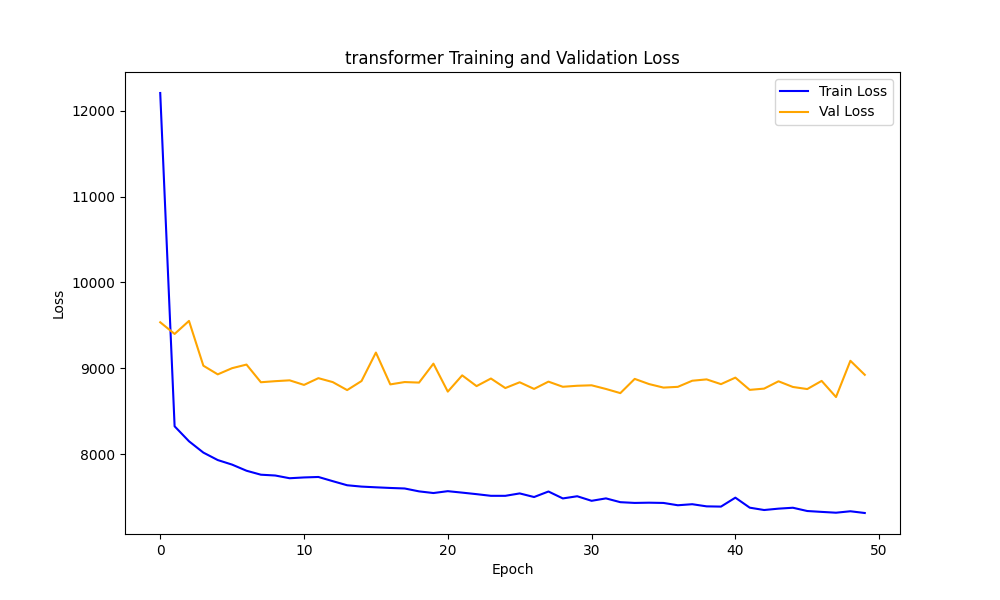

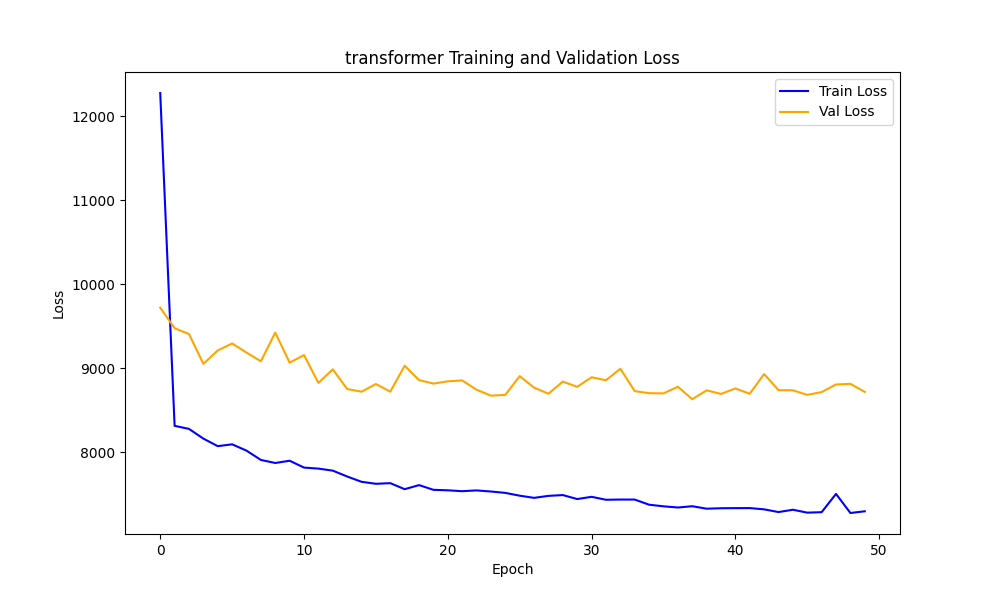

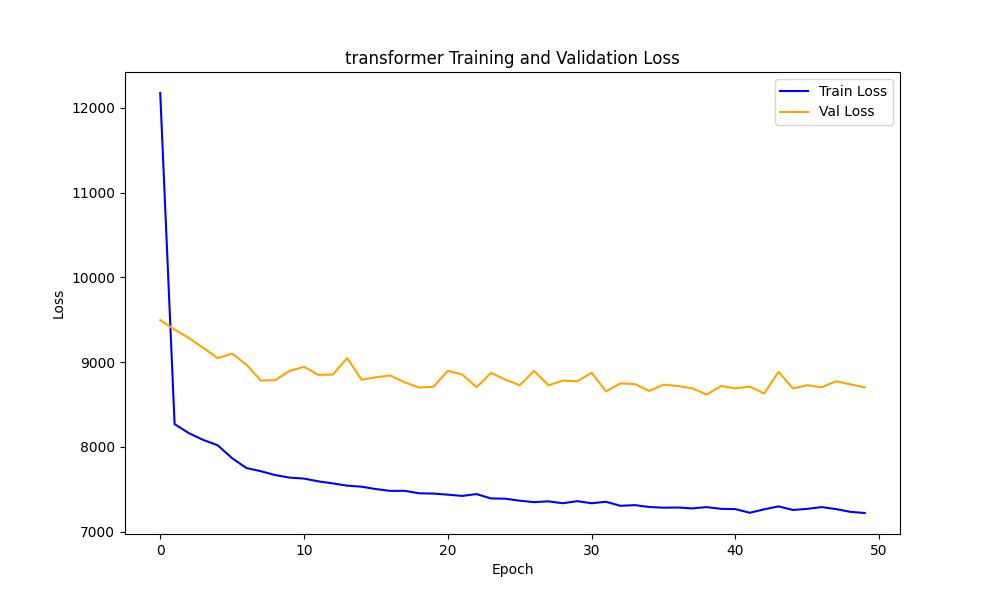

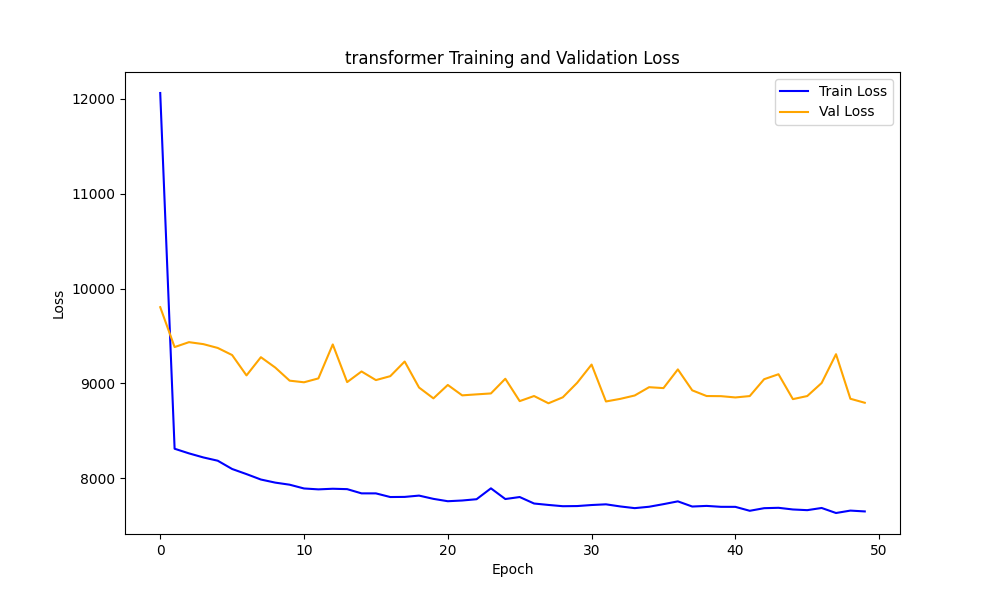

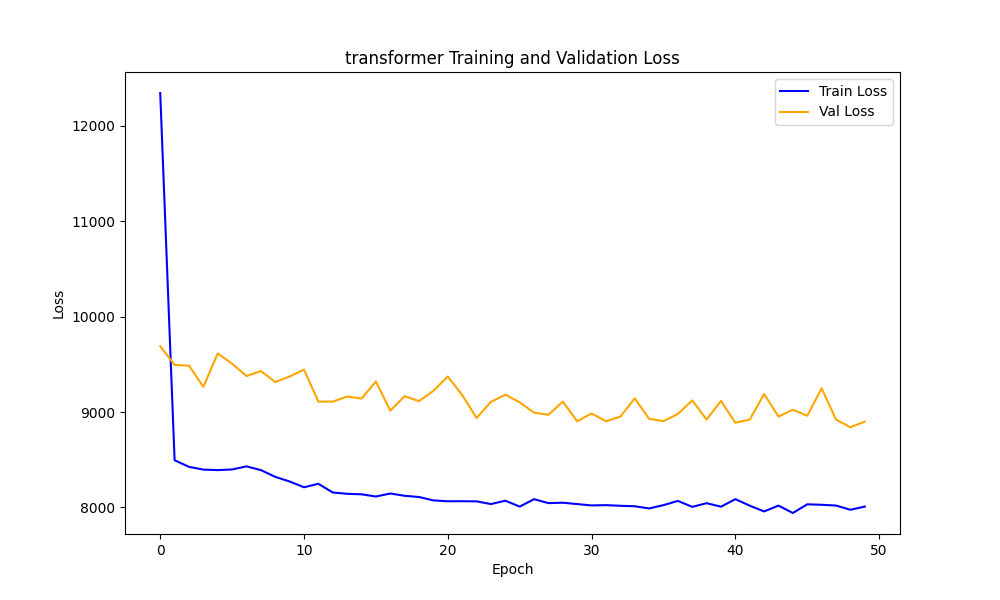

# Top 20 results based on val_mse

In [9]:
# Sort the dataframe by the 'val_mae' column in ascending order

df_sorted_mse = df.sort_values(by='val_loss', ascending=True)
# Display the top 20 rows of the sorted dataframe
print("Top 20 rows sorted by val_mse:")
display(df_sorted_mse.head(20))

Top 20 rows sorted by val_mse:


,transformer_num_layer,transformer_hidden_size,transformer_nhead,transformer_dropout,model_type,learning_rate,num_layers,fc_hidden_sizes,model_hidden_size,sequence_length,batch_size,val_loss,val_mae
72,2,16,4,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8616.604335,53.474585
68,2,16,2,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8630.799396,53.052134
64,2,16,1,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8664.985853,52.862627
28,1,32,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8773.263330,54.640006
12,1,16,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8791.146553,54.219069
44,1,64,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8791.411473,54.519471
76,2,16,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8822.498728,54.967452
60,1,128,8,0.0,Transformer,0.005,5,512_256_128_64_32,32,30,32,8822.612279,55.202129
65,2,16,1,0.1,Transformer,0.005,5,512_256_128_64_32,32,30,32,8828.800995,54.287753
69,2,16,2,0.1,Transformer,0.005,5,512_256_128_64_32,32,30,32,8840.564161,54.327650


# Aggregate results for each hyperparameter combination by taking the average of val_mae of grouped rows for:

## Num Transformer Layers

In [10]:
# Group the dataframe by 'learn_rate' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df = df.groupby('transformer_num_layer')[['val_mae', 'val_loss']].mean().reset_index()

# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_mae = grouped_df.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
display(grouped_df_sorted_mae)

,transformer_num_layer,val_mae,val_loss
0,1,57.723643,9567.380099
1,2,59.267043,9786.700908
2,4,95.312727,21479.534985


## Transformers Hidden Size

In [11]:
# Group the dataframe by 'model_hidden_size' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df_hidden_size = df.groupby('transformer_hidden_size')[['val_mae', 'val_loss']].mean().reset_index()
# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_hidden_size = grouped_df_hidden_size.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
print("Grouped by transformer_hidden_size:")
display(grouped_df_sorted_hidden_size)

Grouped by transformer_hidden_size:


,transformer_hidden_size,val_mae,val_loss
0,16,64.292356,11756.847624
1,32,71.782701,14023.689164
2,64,73.436911,14328.203472
3,128,73.559249,14336.081063


## Num Attention Heads

In [12]:
# Group the dataframe by 'num_layers' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df_num_layers = df.groupby('transformer_nhead')[['val_mae', 'val_loss']].mean().reset_index()
# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_num_layers = grouped_df_num_layers.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
display(grouped_df_sorted_num_layers)

,transformer_nhead,val_mae,val_loss
2,4,69.554293,13267.560657
3,8,70.146024,13478.742966
1,2,70.553690,13551.160324
0,1,72.817209,14147.357375


## Dropout Rate

In [13]:
# Group the dataframe by 'fc_hidden_sizes' and calculate the mean of 'val_mae' and 'val_loss'
grouped_df_hidden_sizes = df.groupby('transformer_dropout')[['val_mae', 'val_loss']].mean().reset_index()
# Sort the grouped dataframe by 'val_mae' in ascending order
grouped_df_sorted_hidden_sizes = grouped_df_hidden_sizes.sort_values(by='val_mae', ascending=True)
# Display the sorted grouped dataframe
display(grouped_df_sorted_hidden_sizes)

,transformer_dropout,val_mae,val_loss
1,0.1,69.202854,13161.121063
0,0.0,70.666244,13723.069221
2,0.2,70.749555,13569.870638
3,0.3,72.452564,13990.760401


# Conclusion

Optimal hyperparameters for:
- Num Transformer Layers: 1, 2
- Num Attention Heads: 2, 4 or 8
- Dropout Rate: 0.1